In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Read annotation file

In [2]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [3]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm")
paths = os.listdir(path_to_results)

In [4]:
cell_types = [
    "CyclingPro1",
    "EosBasMast1",
    "EosBasMast2",
    "GMP-Neutro"
]

In [5]:
pure_cell_type_solution_dict = {cell_type: [] for cell_type in cell_types}

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    cell_type_file_paths = path_to_results / experiment_folder
    # For all cell types 
    for cell_type in os.listdir(cell_type_file_paths):
        if cell_type in cell_types:
            config_exp_folders = cell_type_file_paths / cell_type
            # For all the experiments in the folders 
            for config_exp_folder in os.listdir(config_exp_folders):
                # Be sure candidates are there 
                if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                    uncertainty_path = config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv"
                    # Be sure uncertainty annotation exists 
                    if uncertainty_path.exists():
                        candidate_with_uncertainty_df = pd.read_csv(uncertainty_path)
                        candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                        pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 6/6 [01:23<00:00, 13.89s/it]


In [6]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [7]:
for cell_type in pure_cell_type_solution_dict_concat:
    print(cell_type)
    print(pure_cell_type_solution_dict_concat[cell_type].loc[:, f"{cell_type}_prop"].max())

CyclingPro1
0.9944819
EosBasMast1
0.6624648
EosBasMast2
0.39154655
GMP-Neutro
0.42635062


### Initialize targets

Only 4 types were optimized 

In [8]:
# Cell type fractions
celltype_fraction = {cell_type: 0.10 for cell_type in cell_types}


columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
    "exploitation_score",
    "exploration_score",
    "weighted_uncertainty_score",
    "metric_response_surface", 
]

### Filter values

In [43]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [44]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered CyclingPro1 number of solutions: 6334
Unfiltered CyclingPro1 number of solutions: 19500 

Filtered EosBasMast1 number of solutions: 10434
Unfiltered EosBasMast1 number of solutions: 27100 

Filtered EosBasMast2 number of solutions: 3194
Unfiltered EosBasMast2 number of solutions: 22100 

Filtered GMP-Neutro number of solutions: 6096
Unfiltered GMP-Neutro number of solutions: 17100 



## Plot cell type proportions vs value of the parameter 

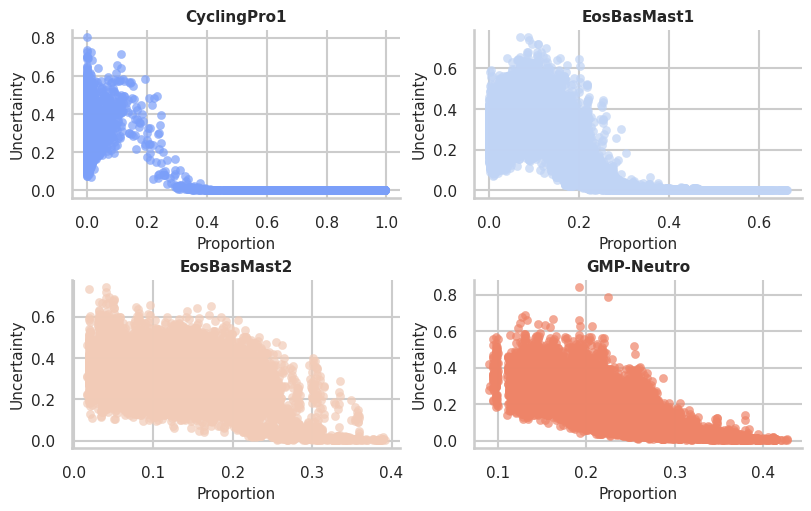

In [45]:
# Theme upgrade
sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)

n = len(celltype_fraction)
cols = int(np.ceil(n / 2))

fig, axes = plt.subplots(
    nrows=2,
    ncols=cols,
    figsize=(8, 5),
    constrained_layout=True  # better than subplots_adjust
)

axes = axes.flatten()

palette = sns.color_palette("coolwarm", n)

for i, (cell_type, color) in enumerate(zip(pure_cell_type_solution_dict_concat, palette)):

    cell_type_safe = cell_type.replace(":", "/")
    df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        y="target_ct_loss_std",
        ax=ax,
        s=35,
        alpha=0.7,
        color=color,
        edgecolor=None,
        linewidth=0.3
    )

    ax.set_title(cell_type, fontsize=11, weight="bold")
    ax.set_xlabel("Proportion", fontsize=11)
    ax.set_ylabel("Uncertainty", fontsize=11)

    ax.tick_params(axis='both', labelsize=11)

    sns.despine(ax=ax)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("Cell Type Proportion vs Loss Uncertainty", fontsize=16, weight="bold")

plt.show()

## Rearrange solutions' columns 

In [46]:
for cell_type in filtered_df:
    # Clean filtered data frames 
    filtered_df[cell_type]= filtered_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    filtered_df[cell_type] = filtered_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

    # Clean unfiltered dataframes 
    annotated_df[cell_type]= annotated_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    annotated_df[cell_type] = annotated_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

## Subsample by uncertainty 

In [47]:
filtered_df_subsample = {}

for cell_type in filtered_df:
    if filtered_df[cell_type].shape[0] > 200:
        filtered_df_subsample_ct = []
        sorted_df_uncertainty = filtered_df[cell_type].sort_values(by="uncertainty_loss", ascending=True)
        filtered_df_subsample_ct.append(sorted_df_uncertainty[:100])
        filtered_df_subsample_ct.append(sorted_df_uncertainty[-100:])
        filtered_df_subsample_ct = pd.concat(filtered_df_subsample_ct, axis=0)
        filtered_df_subsample[cell_type] = filtered_df_subsample_ct
    else:
        filtered_df_subsample[cell_type] = filtered_df[cell_type]

for cell_type in filtered_df_subsample:
    print(cell_type)
    print(filtered_df_subsample[cell_type].shape)

CyclingPro1
(200, 23)
EosBasMast1
(200, 23)
EosBasMast2
(200, 23)
GMP-Neutro
(200, 23)


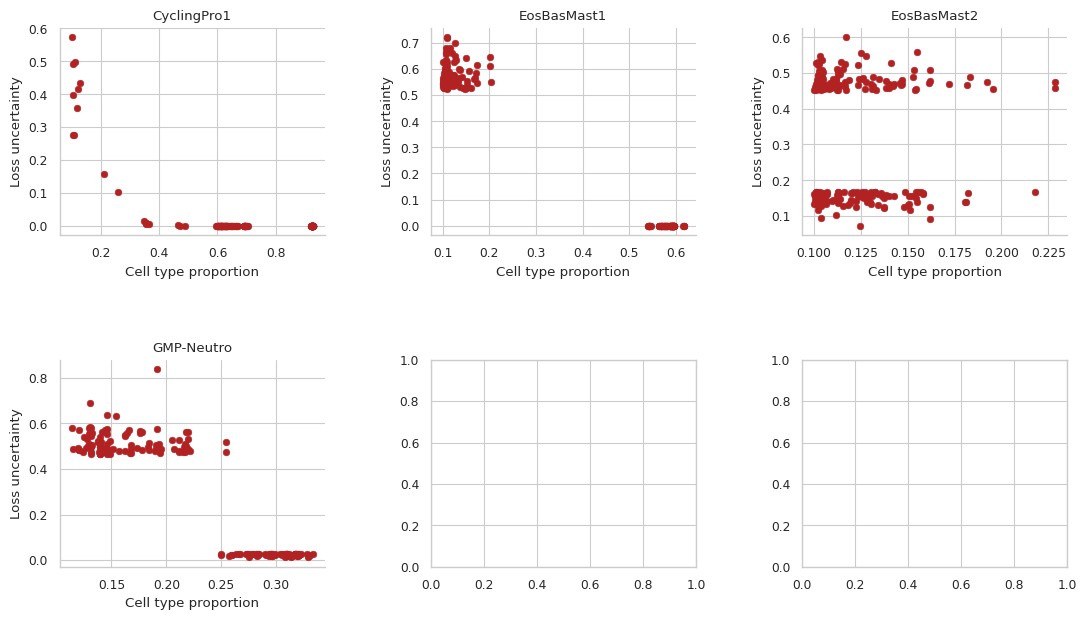

In [48]:
sns.set(style="whitegrid", context="paper")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13,7))
fig.subplots_adjust(
    hspace=0.6,   # vertical space between rows
    wspace=0.4    # horizontal space between columns
)
axes = axes.flatten()  # make indexing easy

for i, cell_type in enumerate(filtered_df_subsample):
    cell_type_safe = cell_type.replace(":", "/")
    df_plot = filtered_df_subsample[cell_type].reset_index(drop=True)

    ax = axes[i]

    sns.scatterplot(
        data=df_plot,
        x=f"{cell_type_safe}_prop",
        y="uncertainty_loss",
        ax=ax,
        edgecolor=None, 
        color="firebrick", 
    )

    # ax.set_yscale("log")   
    ax.set_title(cell_type)
    ax.set_xlabel("Cell type proportion")
    ax.set_ylabel("Loss uncertainty")
    sns.despine(ax=ax)

## Save results

In [49]:
RESULT_PATH = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct")
RESULT_PATH_FILTERED = RESULT_PATH / "filtered"
RESULT_PATH_FILTERED.mkdir(exist_ok=True, parents=True)
RESULT_PATH_ANNOTATED = RESULT_PATH / "annotated"
RESULT_PATH_ANNOTATED.mkdir(exist_ok=True, parents=True)

# Save results 
for cell_type in filtered_df_subsample:
    filtered_df_subsample[cell_type].to_csv(RESULT_PATH / "filtered" / f"filtered_candidates_{cell_type}.csv")
    annotated_df[cell_type].to_csv(RESULT_PATH / "annotated" / f"annotated_candidates_{cell_type}.csv")

In [50]:
# import pickle as pkl 

# with open(RESULT_PATH / "fitlered_populations.pkl", "wb") as file:
#     pkl.dump(filtered_df, file)